# FITS 파일 열어보기

* 이 노트북을 구글 코랩에서 실행하고자 한다면 [파일] - [드라이브에 사본 저장]을 하여 본인의 소유로 만든 후에 코드를 실행하거나 수정할 수 있습니다.

* 이 파일은 실제 수업에 사용하므로 필요에 따라 예고 없이 변경될 수 있습니다.

* If you have any questions or comments on this document, please email me(Kiehyun.Park@gmail.com).

* 이 파일(문서)는 공교육 현장에서 수업시간에 자유롭게 사용할 수 있으나, 다른 목적으로 사용할 시에는 사전에 연락을 주셔서 상의해 주시기 바랍니다.

이 자료는 천체 관측 자료인 FITS 파일을 열어 관련 정보를 알아보는 방법을 설명합니다.

## 필요한 환경

이 프로젝트를 위해서는 아래의 모듈이 필요합니다.

> numpy, matplotlib, astropy, version_information


### 구글 코랩에 한글 폰트 설치

matplotlib에서 한글을 사용하기 위해서는 한글 폰트가 필요하다. 구글 코랩에서 현재의 Jupyter notebook을 실행한다면 아래 코드를 실행 한 후 런타임 다시 시작을 해 줘야 한글을 사용할 수 있을 것이다.

In [1]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

### 런타임 다시 시작

위의 셀을 실행한 다음 반드시 다음 과정을 잊지 말자.

* [메뉴]-[런타임]-[런터임 다시 시작]

* [메뉴]-[런타임]-[이전 셀 실행]을 해주어야 한다.

### 한글 폰트 사용

위에서 한글 폰트를 설치하고, 런타임 다시시작을 했다면 구글 코랩에서 폰트 경로를 설정하여 한글 사용이 가능해 진다.

In [2]:
#visualization
import matplotlib as mpl
import matplotlib.pylab as plb
import matplotlib.pyplot as plt

# 브라우저에서 바로 그려지도록
%matplotlib inline

# 그래프에 retina display 적용
%config InlineBackend.figure_format = 'retina'

# Colab 의 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 유니코드에서  음수 부호설정
mpl.rc('axes', unicode_minus=False)

### 모듈 설치 및 버전 확인

아래 셀을 실행하면 이 노트북을 실행하는데 필요한 모듈을 설치하고 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [3]:
import importlib, sys, subprocess
packages = "numpy, matplotlib, astropy, astroquery, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"**** {pkg} module is now installed.")
    else:
        print(f"******** {pkg} module is already installed.")
%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

******** numpy module is already installed.
******** matplotlib module is already installed.
******** astropy module is already installed.
******** astroquery module is already installed.
******** version_information module is already installed.
This notebook was generated at 2023-09-25 00:11:42 (KST = GMT+0900) 
0 Python     3.11.4 64bit [GCC 11.2.0]
1 IPython    8.12.2
2 OS         Linux 5.15.0 84 generic x86_64 with glibc2.31
3 numpy      1.25.2
4 matplotlib 3.7.2
5 astropy    5.2.1
6 astroquery 0.4.6
7 version_information 1.0.4


## FITS 파일



## 데이터 저장

### FITS 파일 저장 폴더 생성

FITS 파일을 저장할 폴더를 "Comat_fits_files" 이라는 이름으로 생성해보자.

* 만약 리눅스 시스템 이라면 shell 명령어로 가능한데, "!"를 붙이면 shell 명령어를 실행할 수 있다.
> !mkdir Comat_fits_files

OS의 영향을 받지 않기 위하여 pathlib을 사용하여 폴더를 생성해 보자.

In [4]:
import os
from pathlib import Path
BASEPATH = Path("./")
save_dir_name = "Comat_fits_files"
print(f"BASEPATH: {BASEPATH}")

if not (BASEPATH/save_dir_name).exists():
    os.mkdir(str(BASEPATH/save_dir_name))
    print (f"{str(BASEPATH/save_dir_name)} is created...")
else :
    print (f"{str(BASEPATH/save_dir_name)} is already exist...")

BASEPATH: .
Comat_fits_files is already exist...


### FITS 파일 다운로드

나의 구글 드라이브에 저장된 CCD 관측 파일을 다운받아 보겠습니다.

GNU Wget은 HTTP 통신 또는 FTP 통신을 사용해 서버에서 파일 또는 콘텐츠를 다운로드할 때 사용하는 소프트웨어입니다. Wget의 특징은 여러 파일을 한 번에 다운로드하거나 웹 페이지의 링크를 순회하며 여러 콘텐츠를 자동으로 다운로드할 때 매우 편리합니다.

MS Windows에서는 별도로 설치를 해줘야 하며,
구글 코랩도 wget을을 지원해주니 아래 셀을 실행하면 자신의 [작업 영역]에 저장된다. 하지만 이 파일은 이 런타임이 재실행 될때는 삭제됨에 유의하자.

아래 코드를 실행하면 여러분의 작업영역에 해당 파일을 저장할 것이다.



In [5]:
fname1 = "46P-WIRTANEN_LIGHT_R_2018-12-13-17-46-15_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fit"
fid1 = "1qJQdbmdeHg23sPdLKRGfPq93Sfo1HT_3"
fname2 = "46P-WIRTANEN_LIGHT_R_2018-12-13-18-04-52_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fit"
fid2 = "1pjwvAhGXSH35HykK2mMHZ1U5_UoUGbZn"

# wget을 이용(나의 구굴드라이브에서 공유한 파일을 구글 코랩에서 사용할 경우)
!wget --no-check-certificate "https://docs.google.com/uc?export=download&id={fid1}" -O {save_dir_name}/{fname1}
!wget --no-check-certificate "https://docs.google.com/uc?export=download&id={fid2}" -O {save_dir_name}/{fname2}

# gdown을 이용(나의 구굴드라이브에서 공유한 파일을 다운로드)
#!gdown {fid} -O {save_dir_name}/{fname}

--2023-09-25 00:11:42--  https://docs.google.com/uc?export=download&id=1qJQdbmdeHg23sPdLKRGfPq93Sfo1HT_3
Resolving docs.google.com (docs.google.com)... 172.217.25.174, 2404:6800:400a:804::200e
Connecting to docs.google.com (docs.google.com)|172.217.25.174|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-0g-6c-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/noq3tqp9r59i9hpnhi03v8h2qe95nmmr/1695568275000/11752785994579589476/*/1qJQdbmdeHg23sPdLKRGfPq93Sfo1HT_3?e=download&uuid=cde8b7f9-67d8-4961-adee-f1421b336dcd [following]
--2023-09-25 00:11:43--  https://doc-0g-6c-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/noq3tqp9r59i9hpnhi03v8h2qe95nmmr/1695568275000/11752785994579589476/*/1qJQdbmdeHg23sPdLKRGfPq93Sfo1HT_3?e=download&uuid=cde8b7f9-67d8-4961-adee-f1421b336dcd
Resolving doc-0g-6c-docs.googleusercontent.com (doc-0g-6c-docs.googleusercontent.com)... 142.250.206.193, 2404:6800:400a:804::

### 다운로드한 파일 확인

만약 구글 코랩을 사용한다면 오른쪽의 [파일]창에서 확인할 수 있다.

다음의 코드를 실행하면 해당 파일을 확인해 볼 수 있다.

In [6]:
from pathlib import Path
fpaths = sorted(list((BASEPATH/save_dir_name).glob('*')))
print(f"fpaths: {fpaths}")
print(f"len(fpaths): {len(fpaths)}")

fpaths: [PosixPath('Comat_fits_files/46P-WIRTANEN_LIGHT_R_2018-12-13-17-46-15_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fit'), PosixPath('Comat_fits_files/46P-WIRTANEN_LIGHT_R_2018-12-13-18-04-52_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fit'), PosixPath('Comat_fits_files/46P-WIRTANEN_LIGHT_R_2018-12-13-18-04-52_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fits')]
len(fpaths): 3


##  FITS handling

### Read file



In [7]:
from astropy.io import fits
print("fpaths[0]", (fpaths[0]))

hdul = fits.open(str(fpaths[0]))

print("type(hdul) :", type(hdul))
print("hdul :", hdul)

fpaths[0] Comat_fits_files/46P-WIRTANEN_LIGHT_R_2018-12-13-17-46-15_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fit


type(hdul) : <class 'astropy.io.fits.hdu.hdulist.HDUList'>
hdul : [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7fc703190e50>]


HDUList 이므로 그 길이를 알아보자.

In [8]:
print("len(hdul) :", len(hdul))

len(hdul) : 1


dir 함수를 이용하여 객체에 사용할수 있는 mathod를 알아보자.

In [9]:
print("dir(hdul) :", dir(hdul))
print("dir(hdul[0]) :", dir(hdul[0]))

dir(hdul) : ['__add__', '__class__', '__class_getitem__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__imul__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__rmul__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_data', '_file', '_flush_resize', '_flush_update', '_in_read_next_hdu', '_open_kwargs', '_positive_index_of', '_read_all', '_read_next_hdu', '_readfrom', '_resize', '_truncate', '_try_while_unread_hdus', '_verify', '_wasresized', 'append', 'clear', 'close', 'copy', 'count', 'extend', 'fileinfo', 'filename', 'flush', 'fromfile', 'fromstring', 'index', 'index_of', 'info', 'insert', 'pop', 'rea

### header

In [10]:
print("type(hdul[0].hedaer) :", type(hdul[0].header))
#print("hdul[0].hedaer :", hdul[0].header)
hdul[0].header

type(hdul[0].hedaer) : <class 'astropy.io.fits.header.Header'>


SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 1663 / length of data axis 1                          
NAXIS2  =                 1252 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
BSCALE  =                    1 / default scaling factor                         
BZERO   =                32768 / offset data range to that of unsigned short    
PROGRAM = 'PixInsight 1.8.8-7' / Software that created this HDU                 
COLORSPC= 'Grayscale'          / PCL: Color space                               
RESOLUTN=                  72. / PCL: Resolution in pixels per resolution unit  
RESOUNIT= 'inch    '           / PCL: Resolution unit                           
THUMBIMG= 'Thumbnail'       

header는 key와 value가 들어 있다.

In [11]:
print("hdul[0].hedaer['DATE-OBS'] :", hdul[0].header['DATE-OBS'])
print("type(hdul[0].hedaer['DATE-OBS']) :", type(hdul[0].header['DATE-OBS']))

hdul[0].hedaer['DATE-OBS'] : 2018-12-13T17:46:15.000
type(hdul[0].hedaer['DATE-OBS']) : <class 'str'>


### data

관측 자료는 numpy.ndarray 형태로 들어 있음을 알 수 있다.

In [12]:
print("type(hdul[0].data) :", type(hdul[0].data))
print("hdul[0].data.dtype :", hdul[0].data.dtype)
print("hdul[0].data.shape :", hdul[0].data.shape)
print("hdul[0].data :", hdul[0].data)

type(hdul[0].data) : <class 'numpy.ndarray'>
hdul[0].data.dtype : uint16
hdul[0].data.shape : (1252, 1663)
hdul[0].data : [[33368 34170 33854 ... 36466 36010 36280]
 [33296 33358 33634 ... 36270 36458 36298]
 [33778 33790 33436 ... 36250 36342 36420]
 ...
 [33136 32798 32880 ... 34380 34958 35132]
 [33104 33602 33616 ... 34602 35266 34674]
 [32786 33022 32562 ... 35194 34450 35042]]


## Display FITS file

matplotlib을 이용하면 numpy.ndarray를 화면에 디스플레이할 수 있습니다.

### 간단히 한개 파일 display 하기

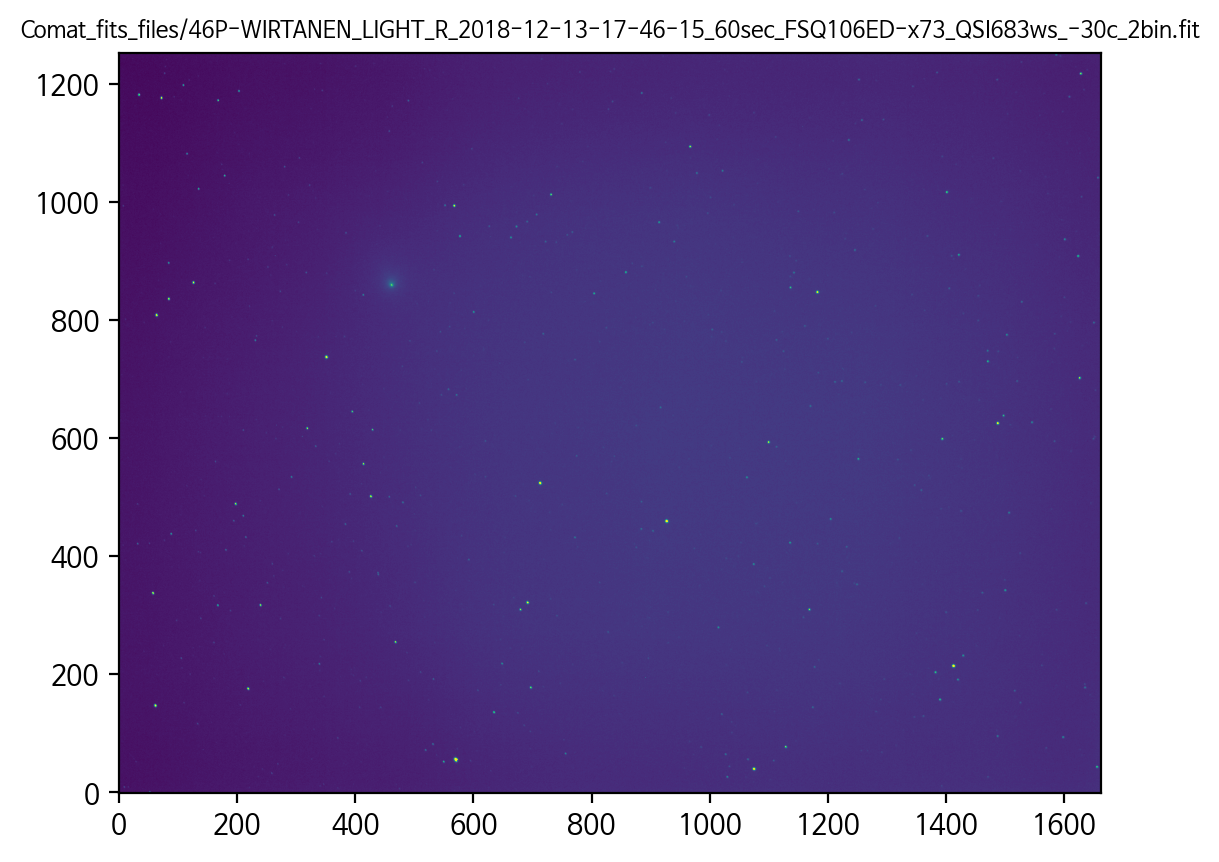

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, NoNorm

plt.imshow(hdul[0].data,
                origin='lower',
                )

plt.title(f'{str(fpaths[0])}', fontsize=8)

plt.show()

### plt.subplots 두개 파일 display

2개 이상의 subplot을 그리는 방법은 여러가지가 있습니다. 아래에 하나의 예시를 보여줍니다.

fpaths[0] Comat_fits_files/46P-WIRTANEN_LIGHT_R_2018-12-13-17-46-15_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fit
fpaths[1] Comat_fits_files/46P-WIRTANEN_LIGHT_R_2018-12-13-18-04-52_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fit


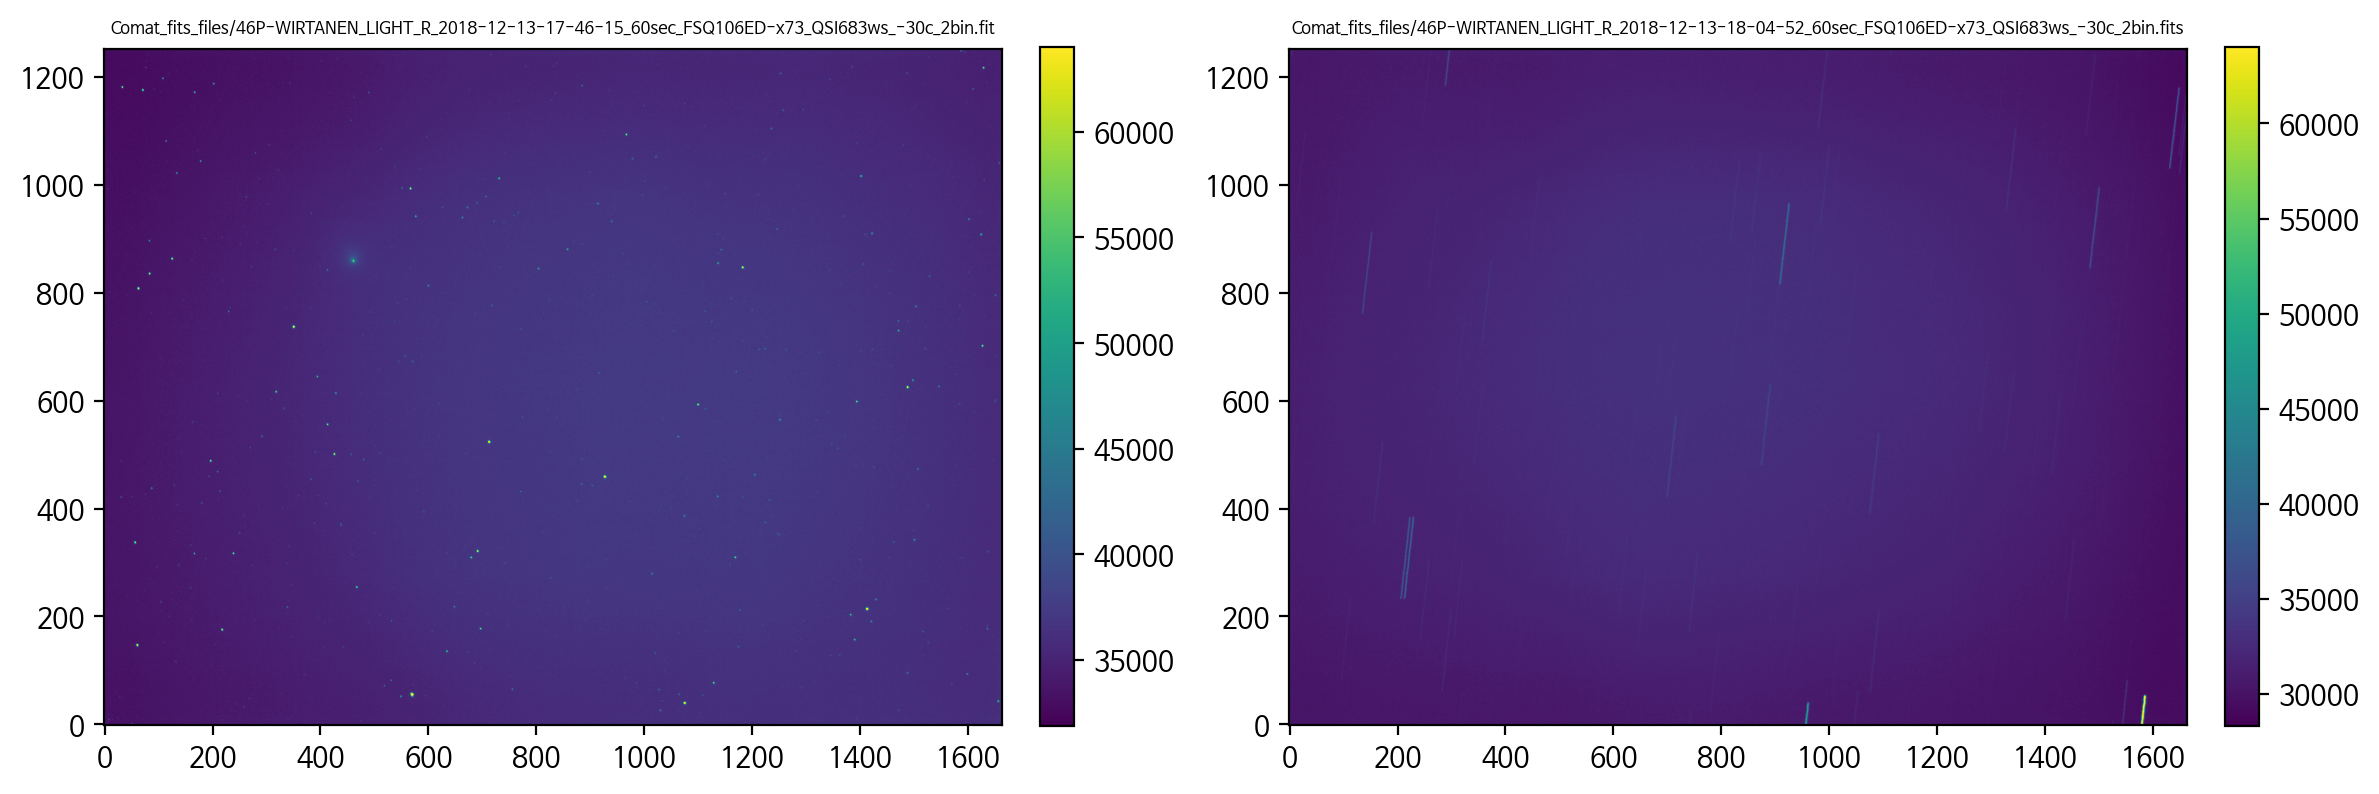

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, NoNorm

print("fpaths[0]", (fpaths[0]))
print("fpaths[1]", (fpaths[1]))

hdul_1 = fits.open(str(fpaths[0]))
hdul_2 = fits.open(str(fpaths[1]))

fig, axs = plt.subplots(1, 2, figsize=(12, 4),
                       sharex=False, sharey=False, gridspec_kw=None)

im1 = axs[0].imshow(hdul_1[0].data,
                origin='lower',
                )
axs[0].set_title(f'{str(fpaths[0])}', fontsize=6)

im2 = axs[1].imshow(hdul_2[0].data,
                origin='lower',
                )
axs[1].set_title(f'{str(fpaths[2])}', fontsize=6)

fig.colorbar(im1, ax = axs[0], fraction=0.035, pad=0.04)
fig.colorbar(im2, ax = axs[1], fraction=0.035, pad=0.04)

plt.tight_layout()

fpaths[2] Comat_fits_files/46P-WIRTANEN_LIGHT_R_2018-12-13-18-04-52_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fits


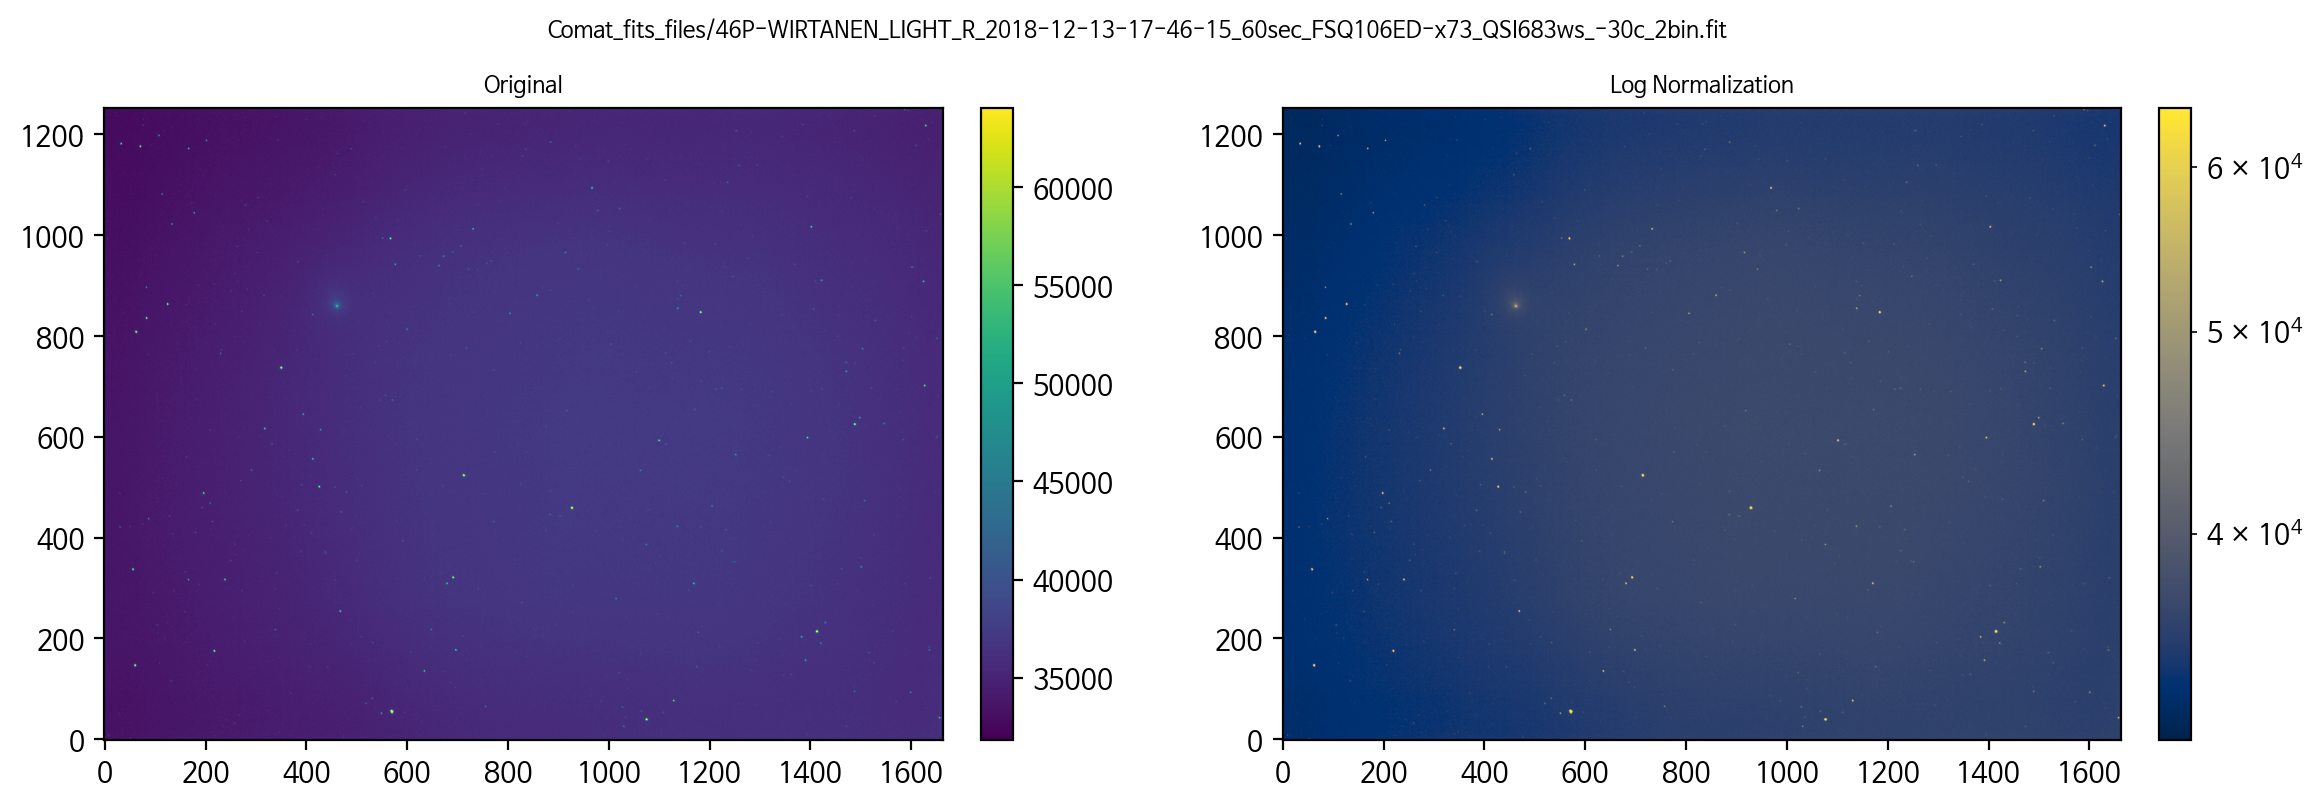

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, NoNorm

print("fpaths[2]", (fpaths[2]))
hdul_2 = fits.open(str(fpaths[2]))


fig, axs = plt.subplots(1, 2, figsize=(12, 4),
                       sharex=False, sharey=False, gridspec_kw=None)

im1 = axs[0].imshow(hdul[0].data,
                origin='lower',
                #norm=LogNorm(),
                #cmap='cividis',
                )
axs[0].set_title('Original', fontsize=8)

im2 = axs[1].imshow(hdul[0].data,
                origin='lower',
                norm=LogNorm(),
                cmap='cividis',
                )
axs[1].set_title('Log Normalization', fontsize=8)

fig.suptitle(f'{str(fpaths[0])}', fontsize=8)
fig.colorbar(im1, ax = axs[0], fraction=0.035, pad=0.04)
fig.colorbar(im2, ax = axs[1], fraction=0.035, pad=0.04)
plt.tight_layout()

## plage solving




### astrometry solving




In [16]:
from astroquery.astrometry_net import AstrometryNet

ast = AstrometryNet()
ast.api_key = 'bldvwzzuvktnwfph'


In [17]:
# solve_timeout = 600
# print(fpaths[0])
# wcs_header = ast.solve_from_image(str(fpaths[0]),
#                         force_image_upload=True,
#                         solve_timeout = solve_timeout,
#                         )

In [18]:
# wcs_header 

In [19]:
# import shutil
# shutil.copy(str(fpaths[0]), str(fpaths[0].parents[0] / f"{fpaths[0].stem}.tmp.fit"))
    
# with fits.open(str(fpaths[0].parents[0] / f"{fpaths[0].stem}.tmp.fit"), mode='update') as filehandle:
#     print("filehandle[0].header", "filehandle[0].header")
#     filehandle[0].header = wcs_header
#     filehandle.flush

# hdul1 = fits.open(str(fpaths[0]))
# #print("type(hdul[0].hedaer) :", type(hdul[0].header))
# #print("hdul[0].hedaer :", hdul[0].header)
# print("hdul1[0].header['B_1_1'] :", hdul1[0].header['B_1_1'])

# hdul2 = fits.open(str(fpaths[0].parents[0] / f"{fpaths[0].stem}.tmp.fit"))
# print("hdul2[0].header['B_1_1'] :", hdul2[0].header['B_1_1'])


In [20]:
import shutil

submission_id = None
solve_timeout = 600

fpath = Path(fpaths[0])
print(fpath)

hdul = fits.open(str(fpath))
if not 'B_1_1' in hdul[0].header :
    try_again = True    

while try_again:
    try:
        if not submission_id:
            wcs_header = ast.solve_from_image(str(fpath),
                                force_image_upload=True,
                                solve_timeout = solve_timeout,
                                submission_id=submission_id)
        else:
            wcs_header = ast.monitor_submission(submission_id,
                                                solve_timeout = solve_timeout)
    except TimeoutError as e:
        submission_id = e.args[1]
    else:
        # got a result, so terminate
        try_again = False

if wcs_header:
    # Code to execute when solve succeeds
    print("fits file solved successfully...")
    shutil.copy(str(fpath), str(fpath.parents[0] / f"{fpath.stem}.tmp"))

    with fits.open(str(fpath.parents[0] / f"{fpath.stem}.tmp"), mode='update') as filehandle:
        print("filehandle[0].header :", filehandle[0].header)
        filehandle[0].header = wcs_header
        filehandle.flush

    shutil.move(str(fpath.parents[0] / f"{fpath.stem}.tmp"), str(fpath.parents[0] / f"{fpath.stem}.fits"))
    print(str(fpath.parents[0] / f'{fpath.stem}.fits')+" is created...")
else:
    # Code to execute when solve fails
    print("fits file solving failure...")

Comat_fits_files/46P-WIRTANEN_LIGHT_R_2018-12-13-17-46-15_60sec_FSQ106ED-x73_QSI683ws_-30c_2bin.fit
Solving..................fits file solved successfully...
filehandle[0].header : SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                   16 / number of bits per data pixel                  NAXIS   =                    2 / number of data axes                            NAXIS1  =                 1663 / length of data axis 1                          NAXIS2  =                 1252 / length of data axis 2                          EXTEND  =                    T / FITS dataset may contain extensions            BSCALE  =                    1 / default scaling factor                         BZERO   =                32768 / offset data range to that of unsigned short    PROGRAM = 'PixInsight 1.8.8-7' / Software that created this HDU                 COLORSPC= 'Grayscale'          / PCL: Color space                               RESOLUTN=          

In [ ]:
# shutil.copy(str(fpath), str(fpath.parents[0] / f"{fpath.stem}.tmp"))

# with fits.open(str(fpath.parents[0] / f"{fpath.stem}.tmp"), mode='update') as filehandle:
#     print("filehandle[0].header", "filehandle[0].header")
#     filehandle[0].header = wcs_header
#     filehandle.flush

# shutil.move(str(fpath.parents[0] / f"{fpath.stem}.tmp"), str(fpath.parents[0] / f"{fpath.stem}.fits"))
